ML-Modeling


In [2]:
# ============================================================================
# FIX: REGISTER VIRTUAL ENVIRONMENT KERNEL
# ============================================================================

import subprocess
import sys
import os

print("=" * 80)
print("🔧 REGISTERING VIRTUAL ENVIRONMENT KERNEL")
print("=" * 80)

# Get the virtual environment Python path
venv_path = os.path.join(os.getcwd(), '.venv', 'Scripts', 'python.exe')

if os.path.exists(venv_path):
    print(f"✅ Found virtual environment: {venv_path}")
    
    # Install ipykernel in virtual environment
    print("\n📦 Installing ipykernel in virtual environment...")
    try:
        subprocess.check_call([
            venv_path, "-m", "pip", "install", "ipykernel", "jupyter"
        ])
        print("✅ ipykernel installed successfully!")
    except Exception as e:
        print(f"⚠️ Error installing ipykernel: {e}")
    
    # Register the kernel
    print("\n📦 Registering kernel...")
    try:
        subprocess.check_call([
            venv_path, "-m", "ipykernel", "install", 
            "--user", 
            "--name", "walmart_venv", 
            "--display-name", "Python (Walmart Project)"
        ])
        print("✅ Kernel registered as 'Python (Walmart Project)'!")
    except Exception as e:
        print(f"⚠️ Error registering kernel: {e}")
    
    print("\n" + "=" * 80)
    print("📌 NEXT STEPS (VERY IMPORTANT):")
    print("=" * 80)
    print("1️⃣ Click on the kernel name in the bottom-right corner")
    print("2️⃣ Select 'Python (Walmart Project)' from the dropdown")
    print("3️⃣ If not visible, click 'Select Kernel' → 'Python Environments'")
    print("4️⃣ Choose 'Python (Walmart Project)'")
    print("5️⃣ Go to Kernel → Restart Kernel")
    print("6️⃣ After restart, run the verification cell below")
    
else:
    print(f"❌ Virtual environment not found at: {venv_path}")
    print("Please make sure you're in the correct directory")

🔧 REGISTERING VIRTUAL ENVIRONMENT KERNEL
✅ Found virtual environment: c:\Users\Usman Ahmad\Desktop\vs code\Datascience- project\.venv\Scripts\python.exe

📦 Installing ipykernel in virtual environment...
✅ ipykernel installed successfully!

📦 Registering kernel...
✅ Kernel registered as 'Python (Walmart Project)'!

📌 NEXT STEPS (VERY IMPORTANT):
1️⃣ Click on the kernel name in the bottom-right corner
2️⃣ Select 'Python (Walmart Project)' from the dropdown
3️⃣ If not visible, click 'Select Kernel' → 'Python Environments'
4️⃣ Choose 'Python (Walmart Project)'
5️⃣ Go to Kernel → Restart Kernel
6️⃣ After restart, run the verification cell below


In [1]:
# ============================================================================
# VERIFY KERNEL AND SKLEARN
# ============================================================================

import sys
print("=" * 80)
print("🔍 VERIFYING KERNEL AND SKLEARN")
print("=" * 80)

# Check Python path
print(f"\n📍 Current Python: {sys.executable}")

# Check if using virtual environment
if '.venv' in sys.executable:
    print("✅ Using virtual environment!")
else:
    print("❌ NOT using virtual environment!")
    print("⚠️ Please select 'Python (Walmart Project)' kernel:")
    print("   Kernel → Change Kernel → Python (Walmart Project)")
    raise SystemExit("Please select the correct kernel")

# Check sklearn
try:
    import sklearn
    print(f"✅ scikit-learn version: {sklearn.__version__}")
    
    # Test imports
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder
    from sklearn.ensemble import RandomForestRegressor
    print("✅ All sklearn modules imported successfully!")
    
    print("\n" + "=" * 80)
    print("🎯 SUCCESS! Ready to run ML Pipeline!")
    print("=" * 80)
    
except ImportError as e:
    print(f"❌ Error: {e}")
    print("\nInstalling scikit-learn in virtual environment...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])

🔍 VERIFYING KERNEL AND SKLEARN

📍 Current Python: c:\Users\Usman Ahmad\Desktop\vs code\Datascience- project\.venv\Scripts\python.exe
✅ Using virtual environment!


✅ scikit-learn version: 1.9.0
✅ All sklearn modules imported successfully!

🎯 SUCCESS! Ready to run ML Pipeline!


🤖 ML PIPELINE WITH L1 & L2 REGULARIZATION
✅ scikit-learn version: 1.9.0

📊 Dataset Shape: (10000, 18)
💰 Total Revenue: $1,155,753.96

🔧 Feature Engineering
--------------------------------------------------------------------------------
✓ Created features: is_weekend, is_holiday

🎯 Feature Selection
--------------------------------------------------------------------------------
Features: 16
Target: revenue

🔢 Encoding Categorical Variables
--------------------------------------------------------------------------------
Categorical columns: ['Branch', 'City', 'category', 'payment_method']
✓ Encoded: Branch
✓ Encoded: City
✓ Encoded: category
✓ Encoded: payment_method

📊 Train-Test Split
--------------------------------------------------------------------------------
Training Set: 8,000 samples
Test Set: 2,000 samples

📊 Feature Scaling
--------------------------------------------------------------------------------
Numerical columns: ['unit_price', 'quantity', 'rating', 'profit_margin'

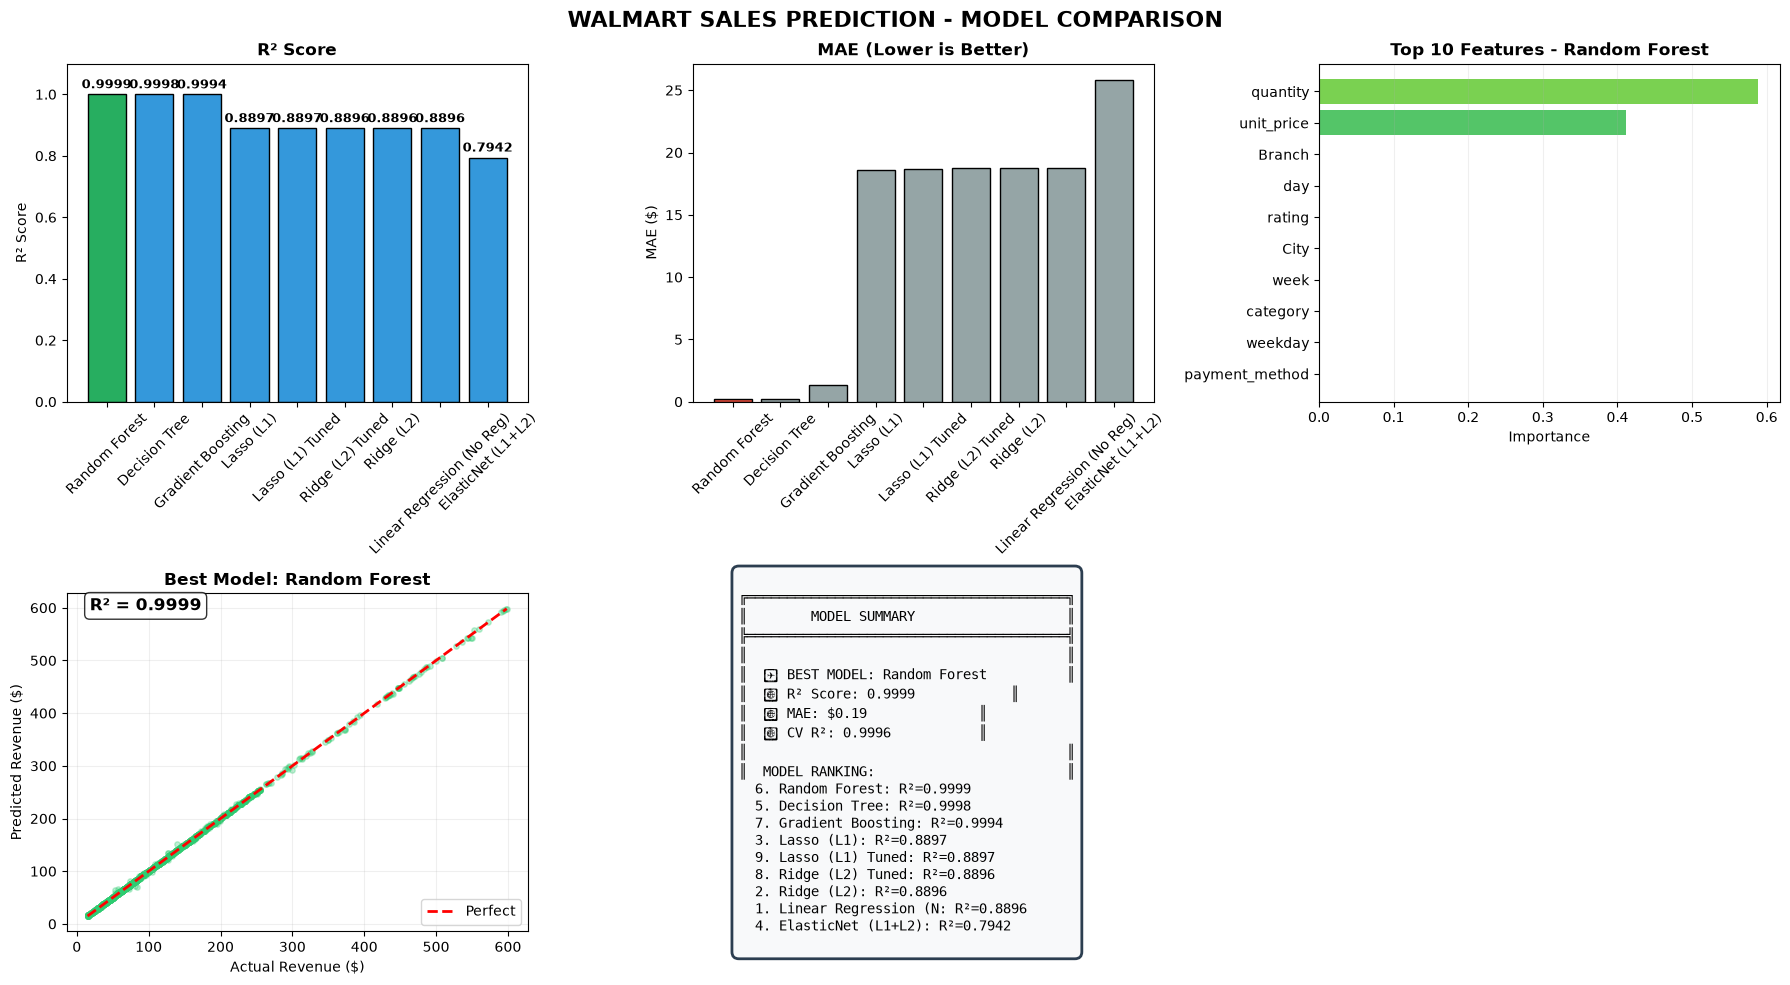


📊 FINAL SUMMARY

✅ BEST MODEL: Random Forest
   R² Score: 0.9999
   MAE: $0.19
   RMSE: $0.91

📊 MODEL RANKING:
   6. Random Forest: R² = 0.9999, MAE = $0.19
   5. Decision Tree: R² = 0.9998, MAE = $0.22
   7. Gradient Boosting: R² = 0.9994, MAE = $1.38
   3. Lasso (L1): R² = 0.8897, MAE = $18.58
   9. Lasso (L1) Tuned: R² = 0.8897, MAE = $18.71
   8. Ridge (L2) Tuned: R² = 0.8896, MAE = $18.72
   2. Ridge (L2): R² = 0.8896, MAE = $18.73
   1. Linear Regression (No Reg): R² = 0.8896, MAE = $18.73
   4. ElasticNet (L1+L2): R² = 0.7942, MAE = $25.85

✅ ML Pipeline Complete!


In [4]:
# ============================================================================
# ML PIPELINE WITH L1 & L2 REGULARIZATION - FIXED VERSION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 80)
print("🤖 ML PIPELINE WITH L1 & L2 REGULARIZATION")
print("=" * 80)
print(f"✅ scikit-learn version: {sklearn.__version__}")

# ============================================================================
# DATA PREPARATION
# ============================================================================

# Load cleaned dataset
df = pd.read_csv(r'C:\Users\Usman Ahmad\Desktop\vs code\Datascience- project\Walmart_Cleaned.csv', parse_dates=['date'])
df['revenue'] = df['unit_price'] * df['quantity']

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"💰 Total Revenue: ${df['revenue'].sum():,.2f}")

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================

print("\n🔧 Feature Engineering")
print("-" * 80)

# Create additional features
df['is_weekend'] = df['weekday'].isin([6, 7]).astype(int)

# Create holiday indicator
if 'is_holiday' not in df.columns:
    holidays = ['01-01', '05-25', '07-04', '09-07', '11-26', '12-25']
    df['is_holiday'] = df['date'].dt.strftime('%m-%d').isin(holidays).astype(int)

print("✓ Created features: is_weekend, is_holiday")

# ============================================================================
# FEATURE SELECTION
# ============================================================================

print("\n🎯 Feature Selection")
print("-" * 80)

# Define features and target
features = [
    'unit_price', 'quantity', 'rating', 'profit_margin',
    'year', 'month', 'week', 'day', 'quarter',
    'weekday', 'is_weekend', 'is_holiday',
    'Branch', 'City', 'category', 'payment_method'
]

target = 'revenue'

X = df[features].copy()
y = df[target].copy()

print(f"Features: {len(features)}")
print(f"Target: {target}")

# ============================================================================
# ENCODE CATEGORICAL VARIABLES
# ============================================================================

print("\n🔢 Encoding Categorical Variables")
print("-" * 80)

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"✓ Encoded: {col}")

# ============================================================================
# TRAIN-TEST SPLIT
# ============================================================================

print("\n📊 Train-Test Split")
print("-" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Set: {X_train.shape[0]:,} samples")
print(f"Test Set: {X_test.shape[0]:,} samples")

# ============================================================================
# SCALE NUMERICAL FEATURES
# ============================================================================

print("\n📊 Feature Scaling")
print("-" * 80)

# Identify numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

# Apply Standard Scaling
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
print("✓ Features scaled successfully")

# ============================================================================
# MODEL TRAINING WITH REGULARIZATION (NO PARALLEL PROCESSING)
# ============================================================================

print("\n🤖 Training Models with L1 & L2 Regularization")
print("=" * 80)

# Define models with regularization - REMOVED n_jobs=-1
models = {
    # Linear models with regularization
    'Linear Regression (No Reg)': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=1.0),
    'ElasticNet (L1+L2)': ElasticNet(alpha=1.0, l1_ratio=0.5),
    
    # Tree-based models - REMOVED n_jobs=-1
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100)
}

# Store results
results = {}

print("\n📊 Training models (this may take a few minutes)...\n")

for name, model in models.items():
    print(f"📊 Training {name}...")
    
    try:
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test_scaled)
        
        # Calculate metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        # Cross-validation score - using fewer folds
        try:
            cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='r2')
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
        except:
            cv_mean = 0
            cv_std = 0
        
        # Store results
        results[name] = {
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'CV Mean': cv_mean,
            'CV Std': cv_std,
            'Model': model,
            'Predictions': y_pred
        }
        
        print(f"  ✓ MAE: ${mae:.2f}")
        print(f"  ✓ RMSE: ${rmse:.2f}")
        print(f"  ✓ R²: {r2:.4f}")
        print(f"  ✓ CV R²: {cv_mean:.4f} (±{cv_std:.4f})")
        print()
        
    except Exception as e:
        print(f"  ❌ Error: {e}\n")

# ============================================================================
# HYPERPARAMETER TUNING (WITHOUT PARALLEL PROCESSING)
# ============================================================================

print("\n" + "=" * 80)
print("🔧 Hyperparameter Tuning (Limited to avoid memory issues)")
print("=" * 80)

# Use limited parameter grids and n_jobs=1
try:
    print("\n📊 Tuning Ridge (L2) Regularization...")
    ridge_params = {'alpha': [0.1, 1.0, 10.0]}  # Reduced options
    ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=3, scoring='r2', n_jobs=1)
    ridge_grid.fit(X_train_scaled, y_train)
    print(f"✓ Best Ridge Alpha: {ridge_grid.best_params_['alpha']}")
    print(f"✓ Best Ridge CV R²: {ridge_grid.best_score_:.4f}")
except Exception as e:
    print(f"⚠️ Ridge tuning skipped: {e}")
    ridge_grid = None

try:
    print("\n📊 Tuning Lasso (L1) Regularization...")
    lasso_params = {'alpha': [0.1, 1.0, 10.0]}  # Reduced options
    lasso_grid = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=3, scoring='r2', n_jobs=1)
    lasso_grid.fit(X_train_scaled, y_train)
    print(f"✓ Best Lasso Alpha: {lasso_grid.best_params_['alpha']}")
    print(f"✓ Best Lasso CV R²: {lasso_grid.best_score_:.4f}")
except Exception as e:
    print(f"⚠️ Lasso tuning skipped: {e}")
    lasso_grid = None

# ============================================================================
# TRAIN TUNED MODELS (IF AVAILABLE)
# ============================================================================

if ridge_grid:
    try:
        print("\n📊 Training Tuned Ridge...")
        ridge_tuned = Ridge(alpha=ridge_grid.best_params_['alpha'])
        ridge_tuned.fit(X_train_scaled, y_train)
        y_pred = ridge_tuned.predict(X_test_scaled)
        
        results['Ridge (L2) Tuned'] = {
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R²': r2_score(y_test, y_pred),
            'CV Mean': ridge_grid.best_score_,
            'CV Std': 0,
            'Model': ridge_tuned,
            'Predictions': y_pred
        }
        print(f"  ✓ R²: {results['Ridge (L2) Tuned']['R²']:.4f}")
    except Exception as e:
        print(f"⚠️ Tuned Ridge failed: {e}")

if lasso_grid:
    try:
        print("\n📊 Training Tuned Lasso...")
        lasso_tuned = Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=5000)
        lasso_tuned.fit(X_train_scaled, y_train)
        y_pred = lasso_tuned.predict(X_test_scaled)
        
        results['Lasso (L1) Tuned'] = {
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R²': r2_score(y_test, y_pred),
            'CV Mean': lasso_grid.best_score_,
            'CV Std': 0,
            'Model': lasso_tuned,
            'Predictions': y_pred
        }
        print(f"  ✓ R²: {results['Lasso (L1) Tuned']['R²']:.4f}")
    except Exception as e:
        print(f"⚠️ Tuned Lasso failed: {e}")

# ============================================================================
# COMPARE ALL MODELS
# ============================================================================

print("\n" + "=" * 80)
print("📊 Model Comparison")
print("=" * 80)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['MAE'] for m in results],
    'RMSE': [results[m]['RMSE'] for m in results],
    'R²': [results[m]['R²'] for m in results],
    'CV R²': [results[m]['CV Mean'] for m in results]
})

comparison_df = comparison_df.sort_values('R²', ascending=False)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# ============================================================================
# VISUALIZATION (SIMPLIFIED)
# ============================================================================

print("\n📊 Generating Visualization...")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('WALMART SALES PREDICTION - MODEL COMPARISON', 
             fontsize=16, fontweight='bold')

# 1. R² Score Comparison
ax1 = axes[0, 0]
colors = ['#27ae60' if i==0 else '#3498db' for i in range(len(comparison_df))]
bars1 = ax1.bar(comparison_df['Model'], comparison_df['R²'], color=colors, edgecolor='black')
ax1.set_title('R² Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='x', rotation=45)

for bar, val in zip(bars1, comparison_df['R²']):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. MAE Comparison
ax2 = axes[0, 1]
colors = ['#e74c3c' if i==0 else '#95a5a6' for i in range(len(comparison_df))]
bars2 = ax2.bar(comparison_df['Model'], comparison_df['MAE'], color=colors, edgecolor='black')
ax2.set_title('MAE (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE ($)')
ax2.tick_params(axis='x', rotation=45)

# 3. Best Model Feature Importance
ax3 = axes[0, 2]
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['Model']

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(10)
    
    ax3.barh(importance_df['Feature'], importance_df['Importance'], 
             color=plt.cm.viridis(np.linspace(0.2, 0.8, len(importance_df))))
    ax3.set_title(f'Top 10 Features - {best_model_name}', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Importance')
    ax3.grid(True, alpha=0.2, axis='x')

# 4. Actual vs Predicted
ax4 = axes[1, 0]
best_pred = results[best_model_name]['Predictions']
best_r2 = results[best_model_name]['R²']

ax4.scatter(y_test, best_pred, alpha=0.3, s=15, c='#2ecc71')
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect')
ax4.set_title(f'Best Model: {best_model_name}', fontsize=12, fontweight='bold')
ax4.set_xlabel('Actual Revenue ($)')
ax4.set_ylabel('Predicted Revenue ($)')
ax4.grid(True, alpha=0.2)
ax4.legend()

ax4.text(0.05, 0.95, f'R² = {best_r2:.4f}', 
         transform=ax4.transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 5. Summary
ax5 = axes[1, 1]
ax5.axis('off')

best = comparison_df.iloc[0]
summary_text = f"""
╔════════════════════════════════════════╗
║        MODEL SUMMARY                   ║
╠════════════════════════════════════════╣
║                                        ║
║  ✅ BEST MODEL: {best['Model']}          ║
║  📊 R² Score: {best['R²']:.4f}            ║
║  📉 MAE: ${best['MAE']:.2f}              ║
║  📊 CV R²: {best['CV R²']:.4f}           ║
║                                        ║
║  MODEL RANKING:                        ║
"""

for i, row in comparison_df.iterrows():
    summary_text += f"  {i+1}. {row['Model'][:20]}: R²={row['R²']:.4f}\n"

ax5.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
         fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", 
                   edgecolor='#2c3e50', linewidth=2))

# 6. Empty (for spacing)
ax6 = axes[1, 2]
ax6.axis('off')

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("📊 FINAL SUMMARY")
print("=" * 80)

best = comparison_df.iloc[0]
print(f"\n✅ BEST MODEL: {best['Model']}")
print(f"   R² Score: {best['R²']:.4f}")
print(f"   MAE: ${best['MAE']:.2f}")
print(f"   RMSE: ${best['RMSE']:.2f}")

print("\n📊 MODEL RANKING:")
for i, row in comparison_df.iterrows():
    print(f"   {i+1}. {row['Model']}: R² = {row['R²']:.4f}, MAE = ${row['MAE']:.2f}")

print("\n" + "=" * 80)
print("✅ ML Pipeline Complete!")
print("=" * 80)